# 🎬 Exploratory Data Analysis (EDA) of Netflix Movies and TV Shows

**Author:** Vebi Adeka Putra

## Objectives
This project aims to explore the Netflix Movies and TV Shows dataset using Python. The analysis focuses on understanding the distribution of content, identifying trends, and extracting insights through data visualization.

## Tools
- Python
- Pandas
- NumPy
- Matplotlib


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles (1).csv


In [42]:
df = pd.read_csv("netflix_titles.csv")

In [43]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [45]:
print("Jumlah baris dan kolom:")
print(df.shape)

Jumlah baris dan kolom:
(8807, 12)


In [46]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [47]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [49]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [48]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


In [50]:
missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum()/len(df))*100
})

missing_df.sort_values(by='Missing Values', ascending=False)

,Missing Values,Percentage (%)
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064
show_id,0,0.000000
type,0,0.000000
title,0,0.000000
release_year,0,0.000000


In [51]:
duplicates = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicates}")

Jumlah data duplikat: 0


In [52]:
df = df.drop_duplicates()

In [53]:
df = df.dropna()

In [54]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


## EDA 1: Distribution of Content Type

This analysis shows the number of Movies and TV Shows available on Netflix.

In [55]:
content_type = df['type'].value_counts()

print(content_type)

type
Movie      5185
TV Show     147
Name: count, dtype: int64


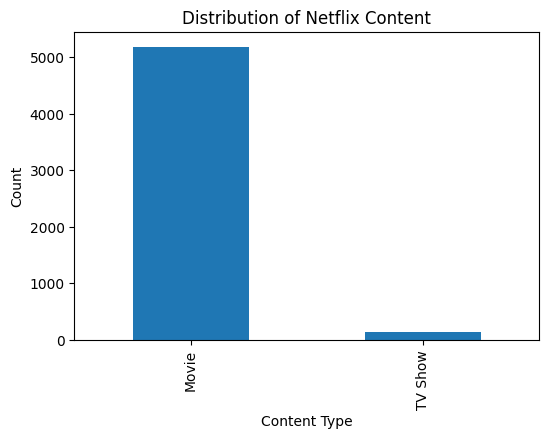

In [56]:
plt.figure(figsize=(6,4))

content_type.plot(kind='bar')

plt.title('Distribution of Netflix Content')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

In [57]:
top_country = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

top_country

,count
country,
United States,1846
India,875
United Kingdom,183
Canada,107
Spain,91
Egypt,90
Nigeria,88
Japan,83
Turkey,79


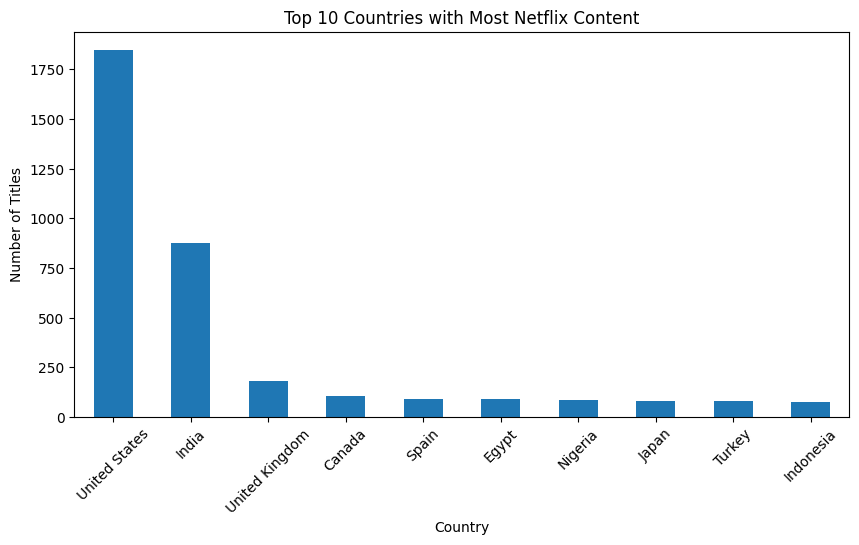

In [58]:
plt.figure(figsize=(10,5))

top_country.plot(kind='bar')

plt.title('Top 10 Countries with Most Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

In [59]:
rating = df['rating'].value_counts()

rating

,count
rating,
TV-MA,1822
TV-14,1214
R,778
PG-13,470
TV-PG,431
PG,275
TV-G,84
TV-Y7,76
TV-Y,76


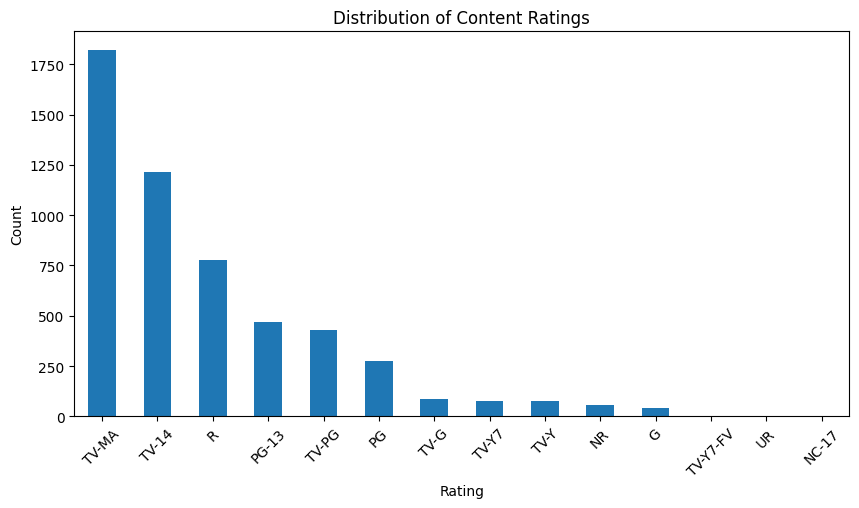

In [60]:
plt.figure(figsize=(10,5))

rating.plot(kind='bar')

plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

In [61]:
release_year = df['release_year'].value_counts().sort_index()

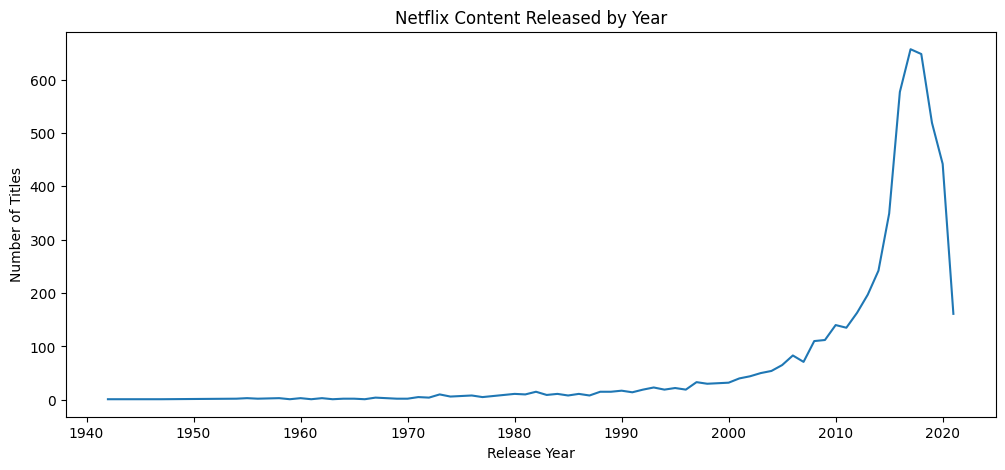

In [62]:
plt.figure(figsize=(12,5))

release_year.plot(kind='line')

plt.title('Netflix Content Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

In [63]:
top_genres = df['listed_in'].value_counts().head(10)

top_genres

,count
listed_in,
"Dramas, International Movies",336
Stand-Up Comedy,286
"Comedies, Dramas, International Movies",257
"Dramas, Independent Movies, International Movies",243
"Children & Family Movies, Comedies",179
"Dramas, International Movies, Romantic Movies",160
Documentaries,156
"Comedies, International Movies",152
"Comedies, International Movies, Romantic Movies",143


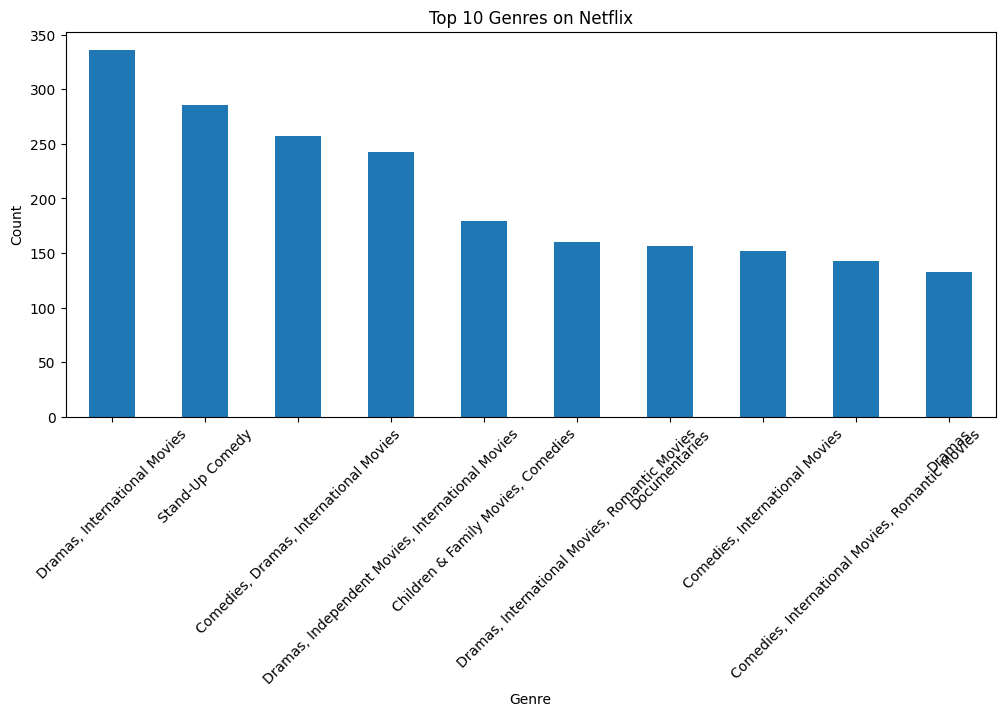

In [64]:
plt.figure(figsize=(12,5))

top_genres.plot(kind='bar')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

In [65]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [66]:
added_year = df['date_added'].dt.year.value_counts().sort_index()

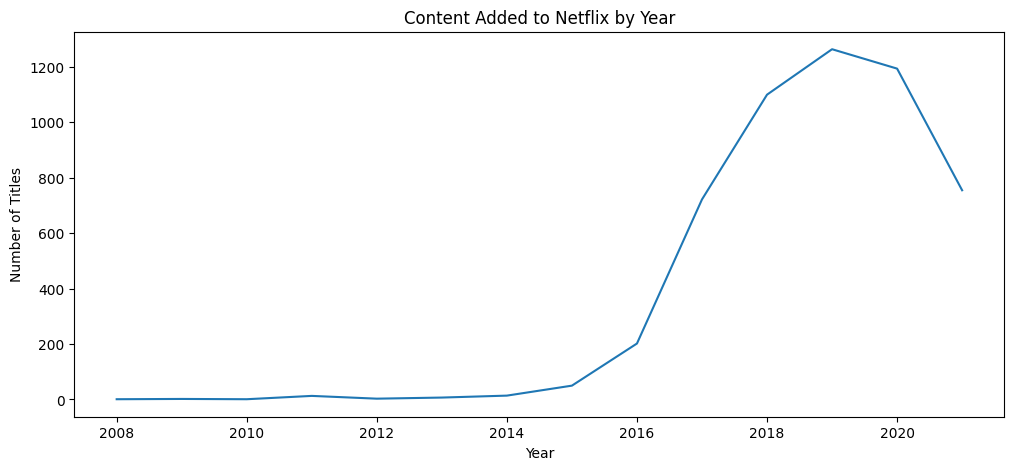

In [67]:
plt.figure(figsize=(12,5))

added_year.plot(kind='line')

plt.title('Content Added to Netflix by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.show()

## Key Insights

- Movies dominate Netflix's content library.
- The United States contributes the highest number of titles.
- TV-MA is the most common content rating.
- Netflix significantly expanded its catalog after 2015.
- Drama and International Movies are among the most common genres.

# Conclusion

This exploratory data analysis provides insights into Netflix's content library. The analysis reveals the distribution of movies and TV shows, identifies the top contributing countries, examines content ratings, explores release trends over time, and highlights the most common genres. These findings demonstrate how Python and data visualization techniques can be used to transform raw data into meaningful business insights.

Project Overview

↓

Import Libraries

↓

Load Dataset

↓

Dataset Overview

↓

Data Cleaning

↓

EDA 1

↓

EDA 2

↓

EDA 3

↓

EDA 4

↓

EDA 5

↓

EDA 6

↓

Key Insights

↓

Conclusion

In [68]:
# Display the first five rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021-09-21,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...


In [69]:
# Check missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,4
release_year,0
rating,0
duration,0


In [70]:
# Visualize content distribution
plt.figure(figsize=(6,4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

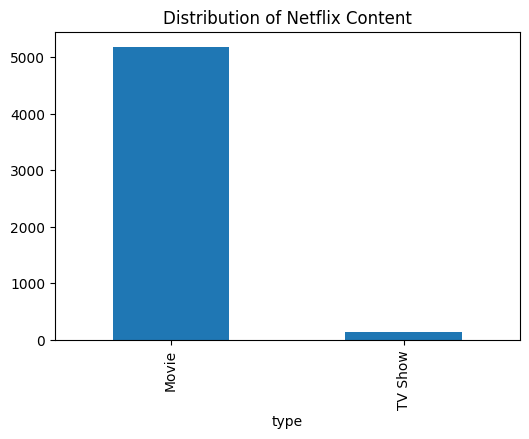

In [71]:
plt.figure(figsize=(6,4))

content_type.plot(kind='bar')

plt.title('Distribution of Netflix Content')

plt.savefig("distribution_content.png", dpi=300)

plt.show()

In [72]:
print("=" * 40)
print("NETFLIX DATASET SUMMARY")
print("=" * 40)
print(f"Total Titles : {len(df)}")
print(f"Movies       : {len(df[df['type']=='Movie'])}")
print(f"TV Shows     : {len(df[df['type']=='TV Show'])}")
print(f"Countries    : {df['country'].nunique()}")
print(f"Genres       : {df['listed_in'].nunique()}")

NETFLIX DATASET SUMMARY
Total Titles : 5332
Movies       : 5185
TV Shows     : 147
Countries    : 604
Genres       : 335
